# Proyek Analisis Data: E-Commerce Public Dataset

**Nama:** Silvana Yulia Damara

## Latar Belakang
Proyek ini bertujuan untuk menganalisis performa bisnis e-commerce berdasarkan data transaksi, kategori produk, dan perilaku pelanggan.

## Pertanyaan Bisnis
1. Kategori produk apa yang menghasilkan jumlah order dan revenue terbesar?
2. Bagaimana tren penjualan dari waktu ke waktu?
3. Bagaimana karakteristik pelanggan berdasarkan RFM analysis?

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os

base_path = "/content/drive/MyDrive/submission_ecommerce"
os.chdir(base_path)

print("Current working directory:", os.getcwd())
print("Isi folder proyek:", os.listdir())

Current working directory: /content/drive/MyDrive/submission_ecommerce
Isi folder proyek: ['README.md', 'requirements.txt', 'url.txt', 'notebook.ipynb', 'data']


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## Data Gathering
Pada tahap ini dilakukan proses pemuatan beberapa file dataset yang relevan untuk analisis, yaitu data pelanggan, order, item order, pembayaran, produk, dan terjemahan kategori produk.

In [14]:
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
payments_df = pd.read_csv("data/order_payments_dataset.csv")
products_df = pd.read_csv("data/products_dataset.csv")
category_df = pd.read_csv("data/product_category_name_translation.csv")

In [15]:
print("customers_df:", customers_df.shape)
print("orders_df:", orders_df.shape)
print("order_items_df:", order_items_df.shape)
print("payments_df:", payments_df.shape)
print("products_df:", products_df.shape)
print("category_df:", category_df.shape)

customers_df: (99441, 5)
orders_df: (99441, 8)
order_items_df: (112650, 7)
payments_df: (103886, 5)
products_df: (32951, 9)
category_df: (71, 2)


In [16]:
display(customers_df.head())
display(orders_df.head())
display(order_items_df.head())
display(payments_df.head())
display(products_df.head())
display(category_df.head())

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## Assessing Data
Tahap ini bertujuan untuk memahami kondisi awal data, seperti tipe data, missing values, dan duplikasi.

In [17]:
def assess_data(df, name):
    print(f"\n=== {name} ===")
    print(df.info())
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nJumlah duplikasi:", df.duplicated().sum())

assess_data(customers_df, "customers_df")
assess_data(orders_df, "orders_df")
assess_data(order_items_df, "order_items_df")
assess_data(payments_df, "payments_df")
assess_data(products_df, "products_df")
assess_data(category_df, "category_df")


=== customers_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Jumlah duplikasi: 0

=== orders_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------

## Data Cleaning
Beberapa proses pembersihan data yang dilakukan:
- Mengubah kolom tanggal menjadi tipe datetime
- Menangani missing value pada kategori produk
- Menggabungkan kategori produk ke bahasa Inggris
- Memfilter order dengan status `delivered` agar analisis penjualan lebih valid

In [18]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(orders_df[col])

products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")

products_df = products_df.merge(
    category_df,
    on="product_category_name",
    how="left"
)

products_df["product_category_name_english"] = products_df["product_category_name_english"].fillna("unknown")

In [19]:
delivered_orders_df = orders_df[orders_df["order_status"] == "delivered"].copy()

print("Jumlah delivered orders:", delivered_orders_df.shape[0])
display(delivered_orders_df.head())

Jumlah delivered orders: 96478


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## Menyiapkan Data untuk Analisis
Pada tahap ini dibuat beberapa tabel turunan:
- data pembayaran per order
- data item order yang sudah memiliki kategori produk
- data level order untuk analisis tren dan RFM

In [20]:
payments_per_order_df = payments_df.groupby("order_id", as_index=False).agg({
    "payment_value": "sum"
}).rename(columns={"payment_value": "total_payment"})

order_items_enriched_df = order_items_df.merge(
    products_df[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)

order_items_enriched_df["product_category_name_english"] = order_items_enriched_df["product_category_name_english"].fillna("unknown")

order_level_df = delivered_orders_df.merge(
    customers_df[["customer_id", "customer_unique_id", "customer_city", "customer_state"]],
    on="customer_id",
    how="left"
).merge(
    payments_per_order_df,
    on="order_id",
    how="left"
)

order_level_df["total_payment"] = order_level_df["total_payment"].fillna(0)

display(order_level_df.head())
print(order_level_df.shape)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_payment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62


(96478, 12)


## Pertanyaan Bisnis 1
### Kategori produk apa yang menghasilkan jumlah order dan revenue terbesar?
Untuk menjawab pertanyaan ini, data item order akan digabungkan dengan data order yang sudah selesai dikirim (`delivered`), lalu dihitung total revenue dan jumlah order per kategori produk.

In [21]:
category_analysis_df = delivered_orders_df[["order_id"]].merge(
    order_items_enriched_df,
    on="order_id",
    how="inner"
)

category_analysis_df["line_revenue"] = category_analysis_df["price"] + category_analysis_df["freight_value"]

category_summary = category_analysis_df.groupby("product_category_name_english", as_index=False).agg({
    "order_id": "nunique",
    "line_revenue": "sum",
    "product_id": "count"
}).rename(columns={
    "product_category_name_english": "product_category",
    "order_id": "total_orders",
    "line_revenue": "total_revenue",
    "product_id": "total_items_sold"
}).sort_values(by="total_revenue", ascending=False)

display(category_summary.head(10))

,product_category,total_orders,total_revenue,total_items_sold
43,health_beauty,8647,1412089.53,9465
71,watches_gifts,5495,1264333.12,5859
7,bed_bath_table,9272,1225209.26,10953
65,sports_leisure,7530,1118256.91,8431
15,computers_accessories,6530,1032723.77,7644
39,furniture_decor,6307,880329.92,8160
49,housewares,5743,758392.25,6795
20,cool_stuff,3559,691680.89,3718
5,auto,3810,669454.75,4140
42,garden_tools,3448,567145.68,4268


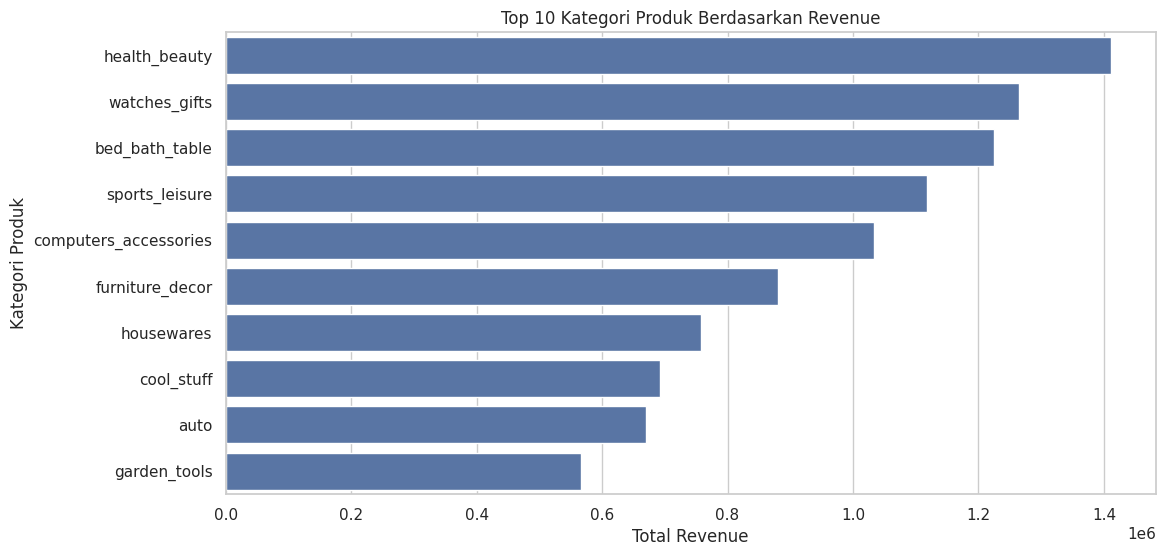

In [22]:
top10_revenue = category_summary.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_revenue, x="total_revenue", y="product_category")
plt.title("Top 10 Kategori Produk Berdasarkan Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Kategori Produk")
plt.show()

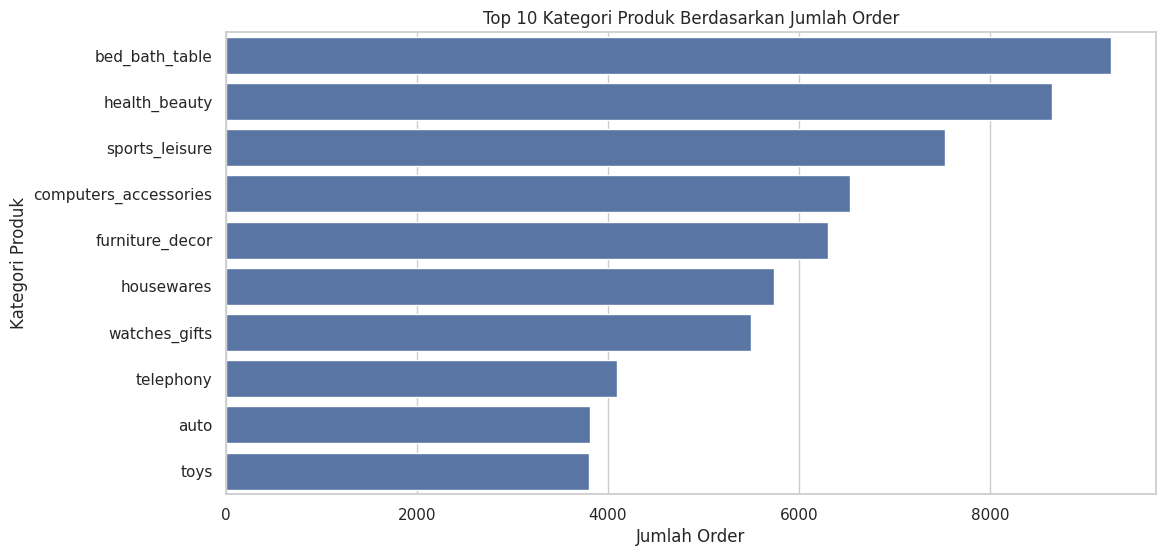

In [23]:
top10_orders = category_summary.sort_values(by="total_orders", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_orders, x="total_orders", y="product_category")
plt.title("Top 10 Kategori Produk Berdasarkan Jumlah Order")
plt.xlabel("Jumlah Order")
plt.ylabel("Kategori Produk")
plt.show()

### Insight Pertanyaan 1
Berdasarkan visualisasi, dapat diidentifikasi kategori produk dengan revenue tertinggi dan kategori dengan jumlah order terbanyak. Hasil ini membantu memahami kategori mana yang paling berkontribusi terhadap performa bisnis.

## Pertanyaan Bisnis 2
### Bagaimana tren penjualan dari waktu ke waktu?
Analisis dilakukan dengan mengelompokkan order berdasarkan bulan transaksi, lalu menghitung jumlah order dan total revenue setiap bulan.

In [24]:
order_level_df["order_month"] = order_level_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

monthly_summary = order_level_df.groupby("order_month", as_index=False).agg({
    "order_id": "nunique",
    "total_payment": "sum"
}).rename(columns={
    "order_id": "total_orders",
    "total_payment": "total_revenue"
}).sort_values(by="order_month")

display(monthly_summary.head())

,order_month,total_orders,total_revenue
0,2016-09,1,0.00
1,2016-10,265,46566.71
2,2016-12,1,19.62
3,2017-01,750,127545.67
4,2017-02,1653,271298.65


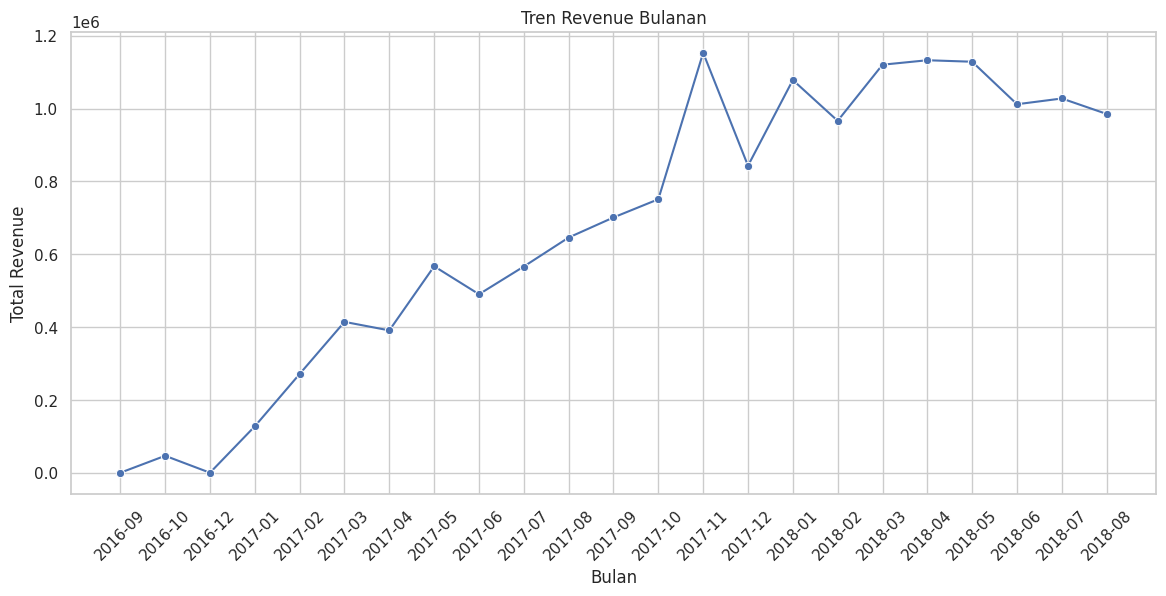

In [25]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_summary, x="order_month", y="total_revenue", marker="o")
plt.title("Tren Revenue Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

### Insight Pertanyaan 2
Visualisasi tren bulanan menunjukkan perubahan performa penjualan dari waktu ke waktu. Dari hasil ini, dapat dilihat bulan dengan performa terbaik maupun terendah.

## Analisis Lanjutan: RFM Analysis
RFM Analysis digunakan untuk memahami perilaku pelanggan berdasarkan tiga aspek:
- **Recency**: seberapa lama sejak terakhir kali pelanggan bertransaksi
- **Frequency**: seberapa sering pelanggan bertransaksi
- **Monetary**: seberapa besar total pengeluaran pelanggan

Analisis ini berguna untuk mengelompokkan pelanggan berdasarkan nilai bisnisnya.

In [26]:
rfm_df = order_level_df.groupby("customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "total_payment": "sum"
}).rename(columns={
    "order_purchase_timestamp": "last_order_date",
    "order_id": "frequency",
    "total_payment": "monetary"
})

reference_date = order_level_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_df["recency"] = (reference_date - rfm_df["last_order_date"]).dt.days

rfm_df = rfm_df[["customer_unique_id", "recency", "frequency", "monetary"]]

display(rfm_df.head())

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [27]:
display(rfm_df.describe())

,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


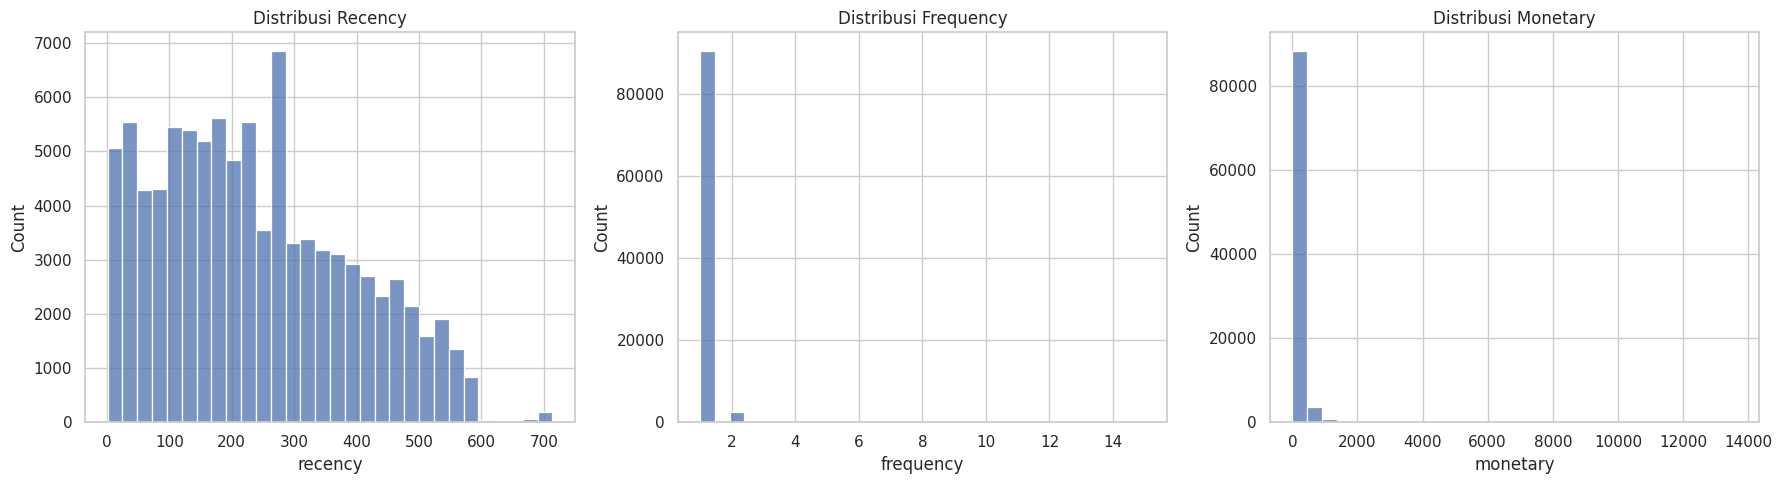

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_df["recency"], bins=30, ax=ax[0])
ax[0].set_title("Distribusi Recency")

sns.histplot(rfm_df["frequency"], bins=30, ax=ax[1])
ax[1].set_title("Distribusi Frequency")

sns.histplot(rfm_df["monetary"], bins=30, ax=ax[2])
ax[2].set_title("Distribusi Monetary")

plt.tight_layout()
plt.show()

In [29]:
rfm_df["R_score"] = pd.qcut(
    rfm_df["recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm_df["F_score"] = pd.qcut(
    rfm_df["frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm_df["M_score"] = pd.qcut(
    rfm_df["monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

In [30]:
def customer_segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Best Customers"
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] == 4 and row["F_score"] <= 2:
        return "New Customers"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk Customers"
    else:
        return "Others"

rfm_df["customer_segment"] = rfm_df.apply(customer_segment, axis=1)

display(rfm_df.head())

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,New Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,Others
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,Others
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,Others
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,Others


In [31]:
segment_summary = rfm_df["customer_segment"].value_counts().reset_index()
segment_summary.columns = ["customer_segment", "total_customers"]

display(segment_summary)

,customer_segment,total_customers
0,Others,34995
1,At Risk Customers,23324
2,Loyal Customers,17258
3,New Customers,11684
4,Best Customers,6097


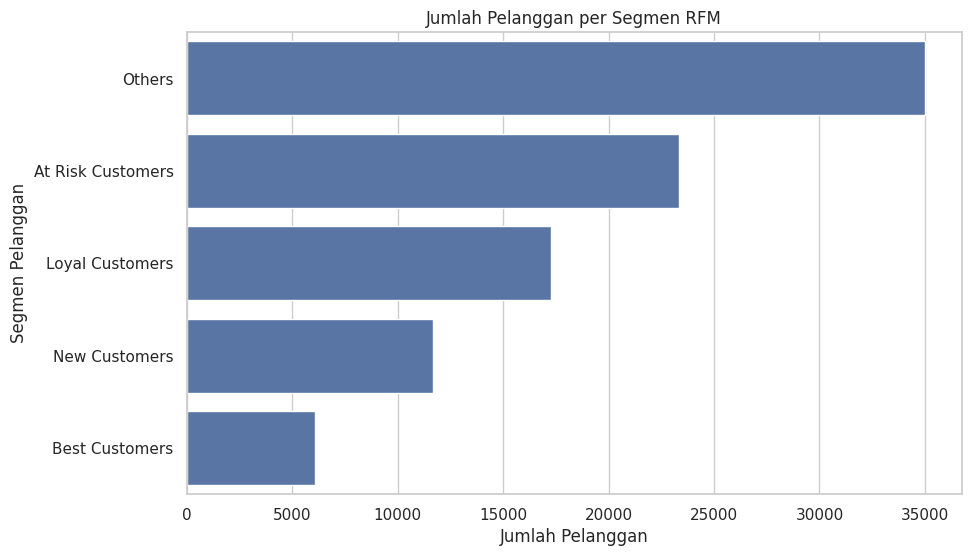

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(data=segment_summary, x="total_customers", y="customer_segment")
plt.title("Jumlah Pelanggan per Segmen RFM")
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Segmen Pelanggan")
plt.show()

### Insight RFM Analysis
Berdasarkan segmentasi RFM, pelanggan dapat dikelompokkan menjadi beberapa segmen seperti **Best Customers**, **Loyal Customers**, **New Customers**, dan **At Risk Customers**. Hasil ini dapat membantu bisnis dalam menyusun strategi retensi pelanggan.

## Conclusion
Bagian ini berisi rangkuman jawaban dari seluruh pertanyaan bisnis yang telah dianalisis.

In [33]:
top_revenue_category = category_summary.iloc[0]
top_order_category = category_summary.sort_values(by="total_orders", ascending=False).iloc[0]
peak_month = monthly_summary.loc[monthly_summary["total_revenue"].idxmax()]
dominant_segment = segment_summary.iloc[0]

print("KESIMPULAN ANALISIS\n")

print(f"1. Kategori produk dengan revenue terbesar adalah '{top_revenue_category['product_category']}' "
      f"dengan total revenue sebesar {top_revenue_category['total_revenue']:.2f}.")

print(f"2. Kategori produk dengan jumlah order terbesar adalah '{top_order_category['product_category']}' "
      f"dengan total order sebanyak {int(top_order_category['total_orders'])} order.")

print(f"3. Penjualan tertinggi terjadi pada bulan {peak_month['order_month']} "
      f"dengan total revenue sebesar {peak_month['total_revenue']:.2f}.")

print(f"4. Segmen pelanggan yang paling dominan adalah '{dominant_segment['customer_segment']}' "
      f"dengan jumlah {int(dominant_segment['total_customers'])} pelanggan.")

KESIMPULAN ANALISIS

1. Kategori produk dengan revenue terbesar adalah 'health_beauty' dengan total revenue sebesar 1412089.53.
2. Kategori produk dengan jumlah order terbesar adalah 'bed_bath_table' dengan total order sebanyak 9272 order.
3. Penjualan tertinggi terjadi pada bulan 2017-11 dengan total revenue sebesar 1153528.05.
4. Segmen pelanggan yang paling dominan adalah 'Others' dengan jumlah 34995 pelanggan.


## Menyimpan Data untuk Dashboard
Pada tahap ini, beberapa data hasil analisis disimpan ke folder `dashboard` agar dapat digunakan dalam pembuatan dashboard Streamlit.

In [34]:
os.makedirs("dashboard", exist_ok=True)

main_data = order_level_df.copy()

main_data.to_csv("dashboard/main_data.csv", index=False)
category_summary.to_csv("dashboard/category_summary.csv", index=False)
monthly_summary.to_csv("dashboard/monthly_summary.csv", index=False)
rfm_df.to_csv("dashboard/rfm_data.csv", index=False)

print("Semua file untuk dashboard berhasil disimpan.")
print(os.listdir("dashboard"))

Semua file untuk dashboard berhasil disimpan.
['main_data.csv', 'category_summary.csv', 'monthly_summary.csv', 'rfm_data.csv']


## Penutup
Analisis menunjukkan bahwa dataset e-commerce dapat memberikan insight penting terkait performa kategori produk, tren penjualan, dan perilaku pelanggan. Dashboard Streamlit akan digunakan sebagai media penyajian hasil analisis secara interaktif.